# Usage of PySpark SQL

In [1]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [2]:
spark

In [3]:
sc = spark.sparkContext

In [4]:
## documentation
spark.read??

In [5]:
file_path = r'/content/article.txt'

In [6]:
article = spark.read.text(file_path)

In [7]:
article

DataFrame[value: string]

In [8]:
article.printSchema()

root
 |-- value: string (nullable = true)



In [9]:
article.select(article.value)

DataFrame[value: string]

In [10]:
article.show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                            |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|NEW YORK — A little over a year ago, the New York City art dealer Robert Ro

In [11]:
from pyspark.sql.functions import col

notes


In [12]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [13]:
from pyspark.sql.functions import col, split

lines = article.select(
    split(col('value'), " ").alias('line')
)

In [14]:
lines.printSchema()

root
 |-- line: array (nullable = true)
 |    |-- element: string (containsNull = false)



In [15]:
lines.show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|line                                                                                                                                                                                                                                                                                                                                                          |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [16]:
lines

DataFrame[line: array<string>]

In [17]:
from pyspark.sql.functions import explode

words = lines.select(explode(col("line")).alias('word'))

In [18]:
words.printSchema()

root
 |-- word: string (nullable = false)



In [19]:
from pyspark.sql.functions import lower

words_lower = words.select(lower(col("word")).alias('word_lower'))

In [20]:
words_lower.show(10)

+----------+
|word_lower|
+----------+
|       new|
|      york|
|         —|
|         a|
|    little|
|      over|
|         a|
|      year|
|      ago,|
|       the|
+----------+
only showing top 10 rows


In [21]:
from pyspark.sql.functions import regexp_extract

words_clean = words_lower.select(
    regexp_extract(col("word_lower"), r"(\W+)?([a-z]+)", 2).alias("word_clean")
)

In [22]:
words_clean.show(10)

+----------+
|word_clean|
+----------+
|       new|
|      york|
|          |
|         a|
|    little|
|      over|
|         a|
|      year|
|       ago|
|       the|
+----------+
only showing top 10 rows


In [23]:
words_nonull = words_clean.where(col("word_clean") != "")

words_nonull.show(100)

+-----------+
| word_clean|
+-----------+
|        new|
|       york|
|          a|
|     little|
|       over|
|          a|
|       year|
|        ago|
|        the|
|        new|
|       york|
|       city|
|        art|
|     dealer|
|     robert|
|      rogal|
|   received|
|          a|
|      visit|
|         to|
|        his|
|    private|
|   showroom|
|       from|
|          a|
|      young|
|      woman|
|        who|
|     seemed|
|      eager|
|         to|
|    offload|
|          a|
|     family|
|   heirloom|
|introducing|
|    herself|
|         as|
|   karolina|
|  bankowska|
|        she|
|    carried|
|          a|
|     framed|
|   painting|
|     signed|
|         by|
|     andrew|
|      wyeth|
| resembling|
|        the|
| watercolor|
| landscapes|
|        the|
| celebrated|
|     artist|
|        had|
|  completed|
|      early|
|         in|
|        his|
|     career|
|  intrigued|
|      rogal|
|   accepted|
|        the|
|      piece|
|         on|
|consi

In [24]:
groups = words_nonull.groupBy(col("word_clean"))

In [25]:
groups

GroupedData[grouping expressions: [word_clean], value: [word_clean: string], type: GroupBy]

In [26]:
counts = groups.count()

In [27]:
counts.orderBy('count', ascending=False).show(10)

+----------+-----+
|word_clean|count|
+----------+-----+
|       the|   45|
|         a|   25|
|        of|   21|
|        to|   20|
|        in|   18|
|       and|   14|
|      said|    9|
|       art|    8|
|        by|    7|
|       for|    7|
+----------+-----+
only showing top 10 rows


In [28]:
import pyspark.sql.functions as F

counts = (
    spark.read.text(file_path)
     .select(F.split(F.col('value'), ' ').alias('line'))
     .select(F.explode(F.col('line')).alias('word'))
     .select(F.lower(F.col('word')).alias('word'))
     .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
     .where(F.col('word') != "")
     .groupby('word')
     .count()
)

In [29]:
counts.show(10)

+---------+-----+
|     word|count|
+---------+-----+
|      art|    8|
|     some|    2|
|      few|    1|
| received|    1|
|  auction|    6|
|    often|    1|
|plausibly|    1|
|   spodek|    1|
|  offload|    1|
|      did|    1|
+---------+-----+
only showing top 10 rows


In [36]:
# remove words with 3 or fewer letters
counts = counts.where(F.length(F.col('word')) > 3)

counts.orderBy(F.desc("count")).show(5)

+--------+-----+
|    word|count|
+--------+-----+
|    said|    9|
|    that|    6|
| auction|    6|
|  artist|    6|
|painting|    5|
+--------+-----+
only showing top 5 rows


In [39]:
# report a table of word lengths and their occurrence frequencies

# create a new column for word length
word_lengths = words.withColumn("word_length", F.length(F.col("word")))

# count how many words occur for each length
length_counts = word_lengths.groupBy("word_length").count()

# sort by word length
length_counts.orderBy("word_length").show()

+-----------+-----+
|word_length|count|
+-----------+-----+
|          0|   20|
|          1|   34|
|          2|  106|
|          3|  129|
|          4|  100|
|          5|   80|
|          6|   79|
|          7|   63|
|          8|   49|
|          9|   37|
|         10|   22|
|         11|   16|
|         12|    8|
|         13|    4|
|         14|    2|
|         15|    5|
|         17|    1|
+-----------+-----+



In [43]:
# split each word into individual letters
letters = words.select(F.explode(F.split(F.col("word"), "")).alias("letter"))

# keep only alphabet letters, just in case
letters = letters.filter(F.col("letter").rlike("[a-zA-Z]"))

# count occurrences of each letter
letter_counts = (
    letters
    .groupBy("letter")
    .count()
    .orderBy(F.desc("count"))
)

letter_counts.show()

+------+-----+
|letter|count|
+------+-----+
|     e|  424|
|     t|  301|
|     a|  289|
|     o|  271|
|     r|  244|
|     i|  242|
|     s|  222|
|     n|  221|
|     d|  158|
|     h|  156|
|     l|  139|
|     c|  104|
|     u|  101|
|     f|   87|
|     p|   77|
|     g|   74|
|     m|   68|
|     w|   59|
|     y|   56|
|     b|   42|
+------+-----+
only showing top 20 rows


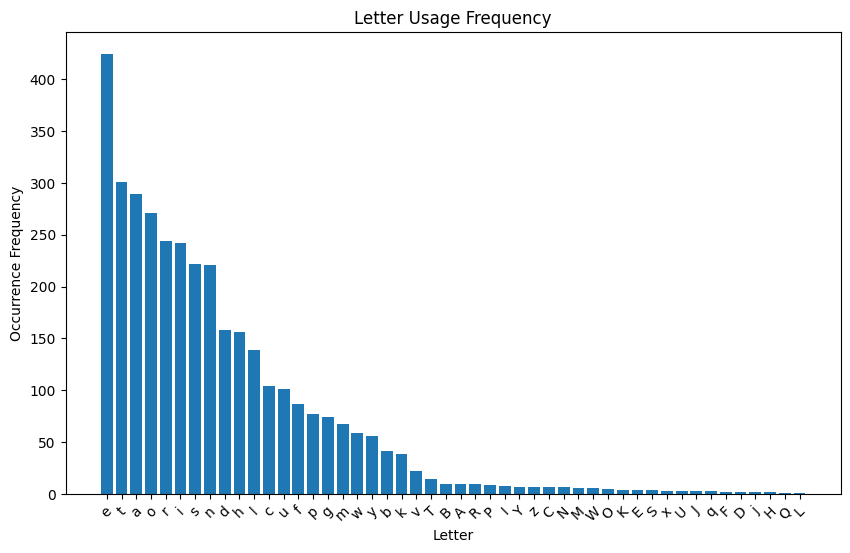

In [44]:
# make a histogram of the occurrences of each alphabet ordered from highest to lowest usage
import matplotlib.pyplot as plt

# convert Spark DataFrame to pandas for plotting
letter_counts_pd = letter_counts.toPandas()

plt.figure(figsize=(10, 6))
plt.bar(letter_counts_pd["letter"], letter_counts_pd["count"])

plt.xlabel("Letter")
plt.ylabel("Occurrence Frequency")
plt.title("Letter Usage Frequency")
plt.xticks(rotation=45)

plt.show()

prof notes


In [ ]:
alphabets = words.select(F.split(F.col('word'), '').alia('letters'))
alphabets.select(F.explode('letters')).show


# gives a col of all alphabets
# then do groupby